In [15]:
import requests
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Pobranie Danych
url = "https://restcountries.com/v3.1/all?fields=name,capital,region,subregion,population,area,currencies"
response = requests.get(url)
response.raise_for_status()
data = response.json()

# Wyciąganie waluty
def get_currency(currencies_dict):
    if currencies_dict and isinstance(currencies_dict, dict):
        return list(currencies_dict.keys())[0]
    return None

# Przetwarzanie Jsona
kraje_lista = []
for kraj in data:
    nazwa = kraj.get("name", {}).get("common")
    stolica = kraj.get("capital", [None])[0] if kraj.get("capital") else None
    region = kraj.get("region")
    subregion = kraj.get("subregion")
    populacja = kraj.get("population")
    powierzchnia = kraj.get("area")
    waluta = get_currency(kraj.get("currencies"))

    kraje_lista.append({
        "nazwa": nazwa,
        "stolica": stolica,
        "region": region,
        "subregion": subregion,
        "populacja": populacja,
        "powierzchnia": powierzchnia,
        "waluta": waluta
    })

df_kraje = pd.DataFrame(kraje_lista)

print(f"Kształt danych (shape): {df_kraje.shape}\n")
print("Typy danych (dtypes):")
print(df_kraje.dtypes)
print("\nPierwsze 5 wierszy:")
display(df_kraje.head())

Kształt danych (shape): (250, 7)

Typy danych (dtypes):
nazwa            object
stolica          object
region           object
subregion        object
populacja         int64
powierzchnia    float64
waluta           object
dtype: object

Pierwsze 5 wierszy:


,nazwa,stolica,region,subregion,populacja,powierzchnia,waluta
0,Cook Islands,Avarua,Oceania,Polynesia,15040,236.0,CKD
1,Guinea,Conakry,Africa,Western Africa,14363931,245857.0,GNF
2,Christmas Island,Flying Fish Cove,Oceania,Australia and New Zealand,1692,135.0,AUD
3,Togo,Lomé,Africa,Western Africa,8095498,56785.0,XOF
4,Taiwan,Taipei,Asia,Eastern Asia,23317031,36197.0,TWD


In [16]:
# Połączenie z bazą
conn = sqlite3.connect("kraje_swiata.db")

# Zapis DataFrame do tabeli
df_kraje.to_sql("kraje", conn, if_exists="replace", index=False)

print("Dane zapisane w 'kraje_swiata.db'.")

Dane zapisane w 'kraje_swiata.db'.


In [17]:
#Łączna populacja świata
df_pop_swiata = pd.read_sql_query("""
    SELECT SUM(populacja) AS laczna_populacja_swiata
    FROM kraje
""", conn)
print("1. Łączna populacja świata:")
display(df_pop_swiata)

# 10 krajów z najw. poulacją
df_top10_pop = pd.read_sql_query("""
    SELECT nazwa, populacja
    FROM kraje
    ORDER BY populacja DESC
    LIMIT 10
""", conn)
print("\n2. Top 10 krajów z największą populacją:")
display(df_top10_pop)

# Ile krajów jest w każdym regionie i jaka jest śr. populacja
df_regiony_stat = pd.read_sql_query("""
    SELECT
        region,
        COUNT(*) AS liczba_krajow,
        ROUND(AVG(populacja), 0) AS srednia_populacja
    FROM kraje
    WHERE region IS NOT NULL
    GROUP BY region
    ORDER BY liczba_krajow DESC
""", conn)
print("\n3. Statystyki regionów:")
display(df_regiony_stat)

#  Kraje z powierzchnią większą nić Polska
df_wieksze_niz_pl = pd.read_sql_query("""
    SELECT nazwa, powierzchnia
    FROM kraje
    WHERE powierzchnia > 312679
    ORDER BY powierzchnia DESC
""", conn)
print(f"\n4. Kraje większe niż Polska (jest ich {len(df_wieksze_niz_pl)}):")
display(df_wieksze_niz_pl.head(10))

#  Który kraj ma najwyższą gęstość zaludnienia
df_gestosc = pd.read_sql_query("""
    SELECT
        nazwa,
        populacja,
        powierzchnia,
        (populacja * 1.0 / powierzchnia) AS gestosc_zaludnienia
    FROM kraje
    WHERE powierzchnia > 0
    ORDER BY gestosc_zaludnienia DESC
    LIMIT 1
""", conn)
print("\n5. Kraj z najwyższą gęstością zaludnienia:")
display(df_gestosc)

1. Łączna populacja świata:


,laczna_populacja_swiata
0,8019495460



2. Top 10 krajów z największą populacją:


,nazwa,populacja
0,India,1417492000
1,China,1408280000
2,United States,340110988
3,Indonesia,284438782
4,Pakistan,241499431
5,Nigeria,223800000
6,Brazil,213421037
7,Bangladesh,169828911
8,Russia,146028325
9,Mexico,130575786



3. Statystyki regionów:


,region,liczba_krajow,srednia_populacja
0,Africa,59,24787532.0
1,Americas,56,18617496.0
2,Europe,53,13993546.0
3,Asia,50,94494639.0
4,Oceania,27,1779988.0
5,Antarctic,5,340.0



4. Kraje większe niż Polska (jest ich 71):


,nazwa,powierzchnia
0,Russia,17098246.0
1,Antarctica,14000000.0
2,Canada,9984670.0
3,China,9706961.0
4,United States,9525067.0
5,Brazil,8515767.0
6,Australia,7692024.0
7,India,3287263.0
8,Argentina,2780400.0
9,Kazakhstan,2724900.0



5. Kraj z najwyższą gęstością zaludnienia:


,nazwa,populacja,powierzchnia,gestosc_zaludnienia
0,Macau,685900,30.0,22863.333333


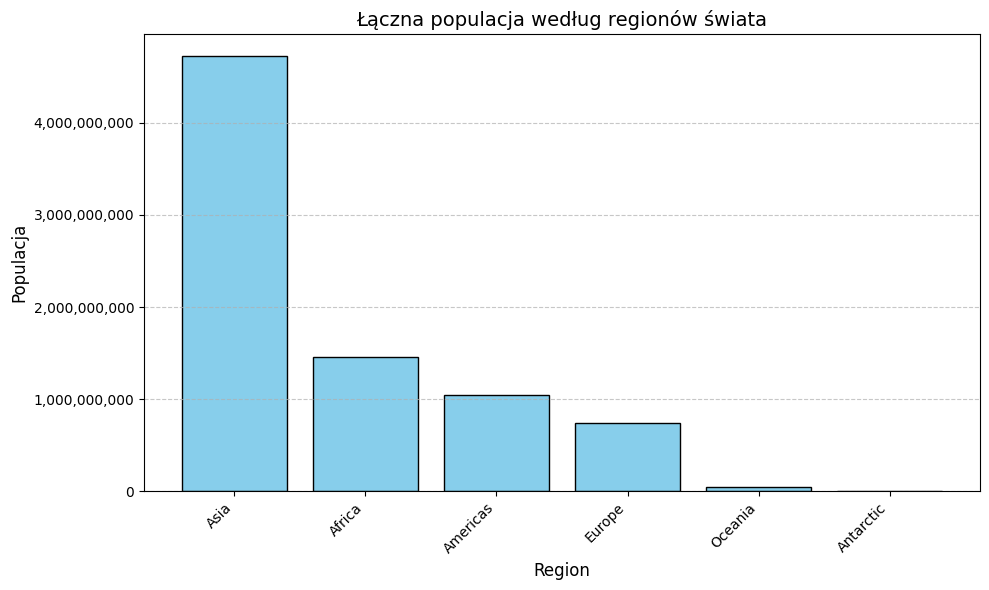

In [18]:
# Pobranie danych
df_wykres = pd.read_sql_query("""
    SELECT region, SUM(populacja) AS populacja_regionu
    FROM kraje
    WHERE region IS NOT NULL
    GROUP BY region
    ORDER BY populacja_regionu DESC
""", conn)

# Tworzenie wykresu słupkowego
plt.figure(figsize=(10, 6))
bars = plt.bar(df_wykres["region"], df_wykres["populacja_regionu"], color='skyblue', edgecolor='black')

plt.title("Łączna populacja według regionów świata", fontsize=14)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Populacja", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

#  poprawa formatowania
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()
conn.close()